# Praktikum Pertemuan 3 — Menyiapkan Data Proyek agar Layak dan Aman Dianalisis

**Mata Kuliah:** Exploratory Data Analysis (KMTI21133) — Pertemuan 3  
**Fase PjBL:** Perencanaan  
**Sub-CPMK3:** Mahasiswa mampu merumuskan pertanyaan analisis dari masalah nyata serta memperoleh data
sesuai lisensi sumbernya, serta mengidentifikasi dan menangani data pribadi yang terkandung di dalamnya (C4, A3).

**Cara kerja.** Sel bertanda `# TODO` Anda kerjakan sendiri; setiap TODO disertai *expected output* agar Anda bisa memeriksa jawaban sendiri. Sel Markdown bertanda **Jawaban Anda** diisi dengan tulisan, bukan kode.

**Bagian A–F** dikerjakan di kelas dengan dataset latihan. **Bagian G** dikerjakan bersama tim di luar kelas dengan dataset proyek Anda sendiri, dan hasilnya menjadi isi **M1 (bobot 5%)** yang dikumpulkan sesuai tenggat di LMS.

## Bagian 0 — Persiapan

Dataset latihan: **`peserta_pelatihan_umkm_2025.csv`** — 620 baris, 28 kolom.
Data pendaftaran dan hasil pelatihan UMKM binaan kampus.

> **Catatan penting:** seluruh isi dataset ini **sintetis** dan dibuat untuk latihan. Tidak ada orang nyata di dalamnya.
> Nomor NIK, nomor telepon, dan surel sengaja dibuat dengan pola yang tidak valid. Perlakukan tetap seolah-olah data nyata,
> karena itulah kebiasaan yang sedang kita latih.

In [1]:
import pandas as pd
import numpy as np
import hashlib, os

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)
print('pandas', pd.__version__)

pandas 2.2.3


In [2]:
FILE = 'peserta_pelatihan_umkm_2025.csv'

if not os.path.exists(FILE):
    try:
        from google.colab import files
        files.upload()          # pilih peserta_pelatihan_umkm_2025.csv
    except ImportError:
        raise FileNotFoundError('Letakkan CSV di folder yang sama dengan notebook ini.')

df = pd.read_csv(FILE)
print(df.shape)
df.head(3)

Saving peserta_pelatihan_umkm_2025.csv to peserta_pelatihan_umkm_2025.csv
(620, 28)


,id_peserta,nama_lengkap,nik_dummy,no_hp,email,alamat_jalan,kelurahan,kecamatan,kota,tanggal_lahir,jenis_kelamin,pendidikan_terakhir,status_disabilitas,jumlah_anak,penghasilan_pribadi_bulanan,nama_usaha,kategori_usaha,produk_utama,lama_usaha_tahun,jumlah_karyawan,omzet_usaha_bulanan,pernah_ikut_pelatihan,kanal_pendaftaran,tanggal_daftar,kehadiran_persen,skor_prates,skor_pascates,tingkat_kepuasan
0,PLT-2025-1309,Ratna Hidayat,99991405899249,8.000426e+10,ratna.hidayat@contoh.example,Jl. Cempaka No. 106 RT 02/RW 10,Sukatani,Tapos,Depok,1989-05-14,P,SMP,Tidak,3,500000,CV Mandiri Jaya,Kuliner,Roti dan kue,12.8,4,2950000,Tidak,Datang langsung,2025-04-04,75,52,67.0,5.0
1,PLT-2025-1512,Bunga Santoso,99992410874363,8.000347e+10,bunga.santoso@contoh.example,Jl. Bougenville No. 80 RT 10/RW 02,Mampang,Pancoran Mas,Depok,1987-10-24,P,D3,Tidak,1,950000,Dapur Cahaya Abadi,Jasa Digital,Servis gawai,6.5,3,7750000,Tidak,Formulir daring,2025-02-02,70,59,75.0,4.9
2,PLT-2025-1360,Endah Ramadhan,99991107987303,8.000266e+10,endah.ramadhan@contoh.example,Jl. Anggrek No. 138 RT 07/RW 08,Limo,Limo,Depok,1998-07-11,P,D3,Tidak,2,1500000,Griya Harum Makmur,Kuliner,Katering rumahan,2.5,0,7550000,Tidak,WhatsApp,2025-03-26,90,51,61.0,4.9


---
## Bagian A — Merumuskan pertanyaan analisis

Sebuah pertanyaan analisis dianggap layak bila lolos **tiga uji**:

1. **Uji kolom** — kolom mana yang akan menjawabnya?
2. **Uji bentuk jawaban** — jawabannya berupa angka, peringkat, perbandingan, atau sebaran?
3. **Uji tindak lanjut** — kalau terjawab, apa yang bisa diputuskan?

In [32]:
# TODO A1 — kenali kolom yang tersedia sebelum menulis pertanyaan
# a. Cetak daftar nama kolom beserta tipe datanya
# b. Cetak jumlah baris dan kolom
# Expected: 620 baris x 28 kolom

#Jawaban :
# a
df.info()
# b
print(df.shape)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         31822 non-null  datetime64[ns]
 1   Location ISO Code            31822 non-null  object        
 2   Location                     31822 non-null  object        
 3   New Cases                    31822 non-null  int64         
 4   New Deaths                   31822 non-null  int64         
 5   New Recovered                31822 non-null  int64         
 6   New Active Cases             31822 non-null  int64         
 7   Total Cases                  31822 non-null  int64         
 8   Total Deaths                 31822 non-null  int64         
 9   Total Recovered              31822 non-null  int64         
 10  Total Active Cases           31822 non-null  int64         
 11  Location Level               31822 non-nu

### TODO A2 — perbaiki tiga pertanyaan berikut

Tulis versi perbaikannya di sel di bawah, beserta kolom yang akan dipakai.

| No | Draf pertanyaan | Masalahnya |
|---|---|---|
| 1 | Bagaimana kondisi peserta pelatihan? | Terlalu kabur |
| 2 | Apakah peserta yang lebih kaya lebih sukses? | "Kaya" dan "sukses" belum didefinisikan sebagai kolom |
| 3 | Apakah pelatihan menaikkan omzet peserta? | Uji kolom gagal — cek sendiri mengapa |

**Jawaban Anda:**

1. Perbaikan: _(Bagaimana sebaran/distribusi tingkat pendidikan terakhir peserta pelatihan?)_ — Kolom: _(pendidikan)_
2. Perbaikan: _(Apakah peserta dengan omzet awal lebih tinggi memiliki nilai post-test / skor evaluasi yang lebih tinggi?)_ — Kolom: _(tulis di sini)_
3. Mengapa uji kolom gagal: _(Uji kolom gagal karena dataset tidak menyediakan kolom omzet setelah/sesudah pelatihan. Data yang tersedia hanya mencatat omzet saat mendaftar/sebelum pelatihan, sehingga perubahan kenaikan omzet tidak dapat diukur.)_

In [4]:
# TODO A3 — buktikan jawaban nomor 3 dengan kode
# Periksa apakah ada kolom omzet SESUDAH pelatihan di dataset ini.
# Petunjuk: cari nama kolom yang memuat kata 'omzet'
# Expected: hanya ada satu kolom omzet, yaitu omzet saat mendaftar
df.filter(like='omzet').columns


Index(['omzet_usaha_bulanan'], dtype='object')

---
## Bagian B — Skala pengukuran

### TODO B1 — klasifikasikan delapan kolom berikut

Isi tabel di sel Markdown ini. Pilihan: **nominal · ordinal · interval · rasio**.

| Kolom | Skala | Alasan singkat |
|---|---|---|
| `kategori_usaha` |nominal| Data kategori label/nama tanpa tingkatan atau urutan alami.|
| `pendidikan_terakhir` |ordinal|Memiliki tingkatan berurutan (SD < SMP < SMA < D3 < S1 < S2), namun jarak antar tingkat tidak terukur pasti.|
| `skor_prates` |interval|Nilai tes memiliki interval terukur, tetapi nilai 0 tidak berarti ketiadaan pengetahuan secara mutlak (tidak memiliki nol mutlak).|
| `omzet_usaha_bulanan` |rasio|Data numerik dengan nol mutlak (Rp0 berarti tidak ada pemasukan) dan operasi perkalian/pembagian bermakna.|
| `jumlah_karyawan` |rasio|Data pencacahan (count) dengan nol mutlak (0 orang berarti tidak ada karyawan).|
| `tingkat_kepuasan` |ordinal|Berupa skala persepsi berurutan (misal: Kurang < Cukup < Puas), jarak antar nilai tidak eksak.|
| `tanggal_daftar` |interval|Satuan waktu kalender memiliki interval yang konsisten (hari/bulan), namun tahun 0 tidak berarti ketiadaan waktu secara mutlak.|
| `kecamatan` |nominal|Data wilayah/nama tempat tanpa peringkat hierarkis.|

In [5]:
# TODO B2 — perbaiki satu kolom ordinal yang salah tipe
import pandas as pd

# a. Jadikan 'pendidikan_terakhir' bertipe kategori berurutan
kategori_pendidikan = ['SD', 'SMP', 'SMA/SMK', 'D3', 'S1', 'S2'] #[cite: 3]
df['pendidikan_terakhir'] = pd.Categorical(
    df['pendidikan_terakhir'],
    categories=kategori_pendidikan,
    ordered=True
)

# b. Tampilkan value_counts() yang sudah urut menurut jenjang (bukan abjad)
print(df['pendidikan_terakhir'].value_counts().sort_index())

# c. Cetak median jenjang pendidikan lewat .cat.codes
median_code = int(df['pendidikan_terakhir'].cat.codes.median())
median_label = kategori_pendidikan[median_code]
print(f"median = {median_label}")


pendidikan_terakhir
SD          24
SMP         71
SMA/SMK    281
D3         107
S1         124
S2          13
Name: count, dtype: int64
median = SMA/SMK


In [6]:
# TODO B3 — ubah dua kolom tanggal menjadi bertipe datetime
# Kolom: tanggal_lahir dan tanggal_daftar
df['tanggal_lahir'] = pd.to_datetime(df['tanggal_lahir'])
df['tanggal_daftar'] = pd.to_datetime(df['tanggal_daftar'])

# Lalu cetak tanggal pendaftaran paling awal dan paling akhir
tgl_awal = df['tanggal_daftar'].min()
tgl_akhir = df['tanggal_daftar'].max()

print("Tanggal pendaftaran paling awal:", tgl_awal)
print("Tanggal pendaftaran paling akhir:", tgl_akhir)


Tanggal pendaftaran paling awal: 2025-02-01 00:00:00
Tanggal pendaftaran paling akhir: 2025-05-31 00:00:00


---
## Bagian C — Kamus data

Kamus data adalah satu baris penjelasan untuk setiap kolom. Bangkitkan kerangkanya dengan kode, isi maknanya sendiri.

In [7]:
# TODO C1 — bangkitkan kerangka kamus data
import pandas as pd

# Buat DataFrame bernama 'kamus'
kamus = pd.DataFrame({
    'nama_kolom': df.columns,
    'tipe_data': [df[col].dtype for col in df.columns],
    'nilai_unik': [df[col].nunique() for col in df.columns],
    'nilai_kosong': [df[col].isna().sum() for col in df.columns],
    'contoh_nilai': [df[col].dropna().iloc[0] if not df[col].dropna().empty else None for col in df.columns]
})

# Tambahkan empat kolom kosong yang akan diisi manual
kolom_manual = ['deskripsi', 'skala_pengukuran', 'kategori_data_pribadi', 'tindakan_penanganan']
for col in kolom_manual:
    kamus[col] = None

# Tampilkan informasi bentuk (Expected: 28 baris x 9 kolom)
print(kamus.shape)
kamus.head()

(28, 9)


,nama_kolom,tipe_data,nilai_unik,nilai_kosong,contoh_nilai,deskripsi,skala_pengukuran,kategori_data_pribadi,tindakan_penanganan
0,id_peserta,object,620,0,PLT-2025-1309,None,None,None,None
1,nama_lengkap,object,450,0,Ratna Hidayat,None,None,None,None
2,nik_dummy,int64,620,0,99991405899249,None,None,None,None
3,no_hp,float64,611,9,80004260813.0,None,None,None,None
4,email,object,450,0,ratna.hidayat@contoh.example,None,None,None,None


In [8]:
# TODO C2 — kolom mana yang punya nilai kosong?
# Tampilkan hanya baris kamus yang nilai_kosong-nya lebih dari 0
kamus_kosong = kamus[kamus['nilai_kosong'] > 0]
kamus_kosong

,nama_kolom,tipe_data,nilai_unik,nilai_kosong,contoh_nilai,deskripsi,skala_pengukuran,kategori_data_pribadi,tindakan_penanganan
3,no_hp,float64,611,9,80004260813.0,None,None,None,None
26,skor_pascates,float64,64,34,67.0,None,None,None,None
27,tingkat_kepuasan,float64,28,18,5.0,None,None,None,None


### TODO C3 — isi kamus untuk lima kolom

Lengkapi tabel berikut. Deskripsi ditulis sebagai kalimat lengkap, bukan pengulangan nama kolom.

| Kolom | Deskripsi | Skala | Satuan |
|---|---|---|---|
| `lama_usaha_tahun` | Durasi waktu operasional usaha yang telah dijalankan oleh peserta hingga saat mendaftar|rasio|Tahun |
| `kehadiran_persen` |Persentase keikutsertaan peserta dalam seluruh sesi kegiatan pelatihan yang diselenggarakan|Rasio|Persen % |
| `skor_pascates` |Nilai evaluasi pemahaman materi yang diperoleh peserta setelah menyelesaikan pelatihan|interval|poin / skor |
| `kanal_pendaftaran` |Saluran atau media yang digunakan peserta untuk mendaftarkan diri pada program pelatihan|Nominal|Kategori (teks)|
| `jumlah_anak` |Total anak kandung atau tanggungan yang dimiliki oleh peserta pelatihan| Rasio|Orang / jiwa|

---
## Bagian D — Menandai data pribadi

| Kategori | Artinya |
|---|---|
| **pengenal langsung** | Sendirian sudah menunjuk ke satu orang |
| **quasi-identifier** | Sendirian aman, gabungannya menunjuk ke satu orang |
| **data spesifik** | Bocornya merugikan lebih berat (kesehatan, keuangan pribadi, data anak) |
| **bukan data pribadi** | Tidak menunjuk ke orang; inilah bahan analisis |

In [9]:
# TODO D1 — susun tabel penandaan Anda sendiri
import pandas as pd

# 1. Definisikan dictionary PENANDAAN yang sesuai persis dengan df.columns
PENANDAAN = {
    # Pengenal langsung (Expected >= 5 kolom)
    'id_peserta': ('pengenal langsung', 'hash'),
    'nama_lengkap': ('pengenal langsung', 'hapus'),
    'nik_dummy': ('pengenal langsung', 'hapus'),
    'no_hp': ('pengenal langsung', 'hash'),
    'email': ('pengenal langsung', 'hash'),
    'alamat_jalan': ('pengenal langsung', 'hapus'),

    # Data spesifik (Expected >= 3 kolom: data anak, keuangan, kesehatan/disabilitas)
    'status_disabilitas': ('data spesifik', 'generalisasi'),
    'jumlah_anak': ('data spesifik', 'generalisasi'),
    'penghasilan_pribadi_bulanan': ('data spesifik', 'generalisasi'),
    'omzet_usaha_bulanan': ('data spesifik', 'generalisasi'),

    # Quasi-identifier (kombinasi demografi/lokasi)
    'tanggal_lahir': ('quasi-identifier', 'generalisasi'),
    'kelurahan': ('quasi-identifier', 'generalisasi'),
    'kecamatan': ('quasi-identifier', 'pertahankan'),
    'kota': ('quasi-identifier', 'pertahankan')
}

# 2. Bangun DataFrame 'tanda' untuk seluruh kolom df
data_tanda = []
for col in df.columns:
    if col in PENANDAAN:
        kat, tind = PENANDAAN[col]
    else:
        kat, tind = 'bukan data pribadi', 'pertahankan'
    data_tanda.append({'nama_kolom': col, 'kategori': kat, 'tindakan': tind})

tanda = pd.DataFrame(data_tanda)

# 3. Cetak jumlah kolom per kategori
print(tanda['kategori'].value_counts())
display(tanda)

kategori
bukan data pribadi    14
pengenal langsung      6
quasi-identifier       4
data spesifik          4
Name: count, dtype: int64


,nama_kolom,kategori,tindakan
0,id_peserta,pengenal langsung,hash
1,nama_lengkap,pengenal langsung,hapus
2,nik_dummy,pengenal langsung,hapus
3,no_hp,pengenal langsung,hash
4,email,pengenal langsung,hash
5,alamat_jalan,pengenal langsung,hapus
6,kelurahan,quasi-identifier,generalisasi
7,kecamatan,quasi-identifier,pertahankan
8,kota,quasi-identifier,pertahankan
9,tanggal_lahir,quasi-identifier,generalisasi


### TODO D2 — pertanggungjawabkan tiga keputusan

Tiga kolom berikut sering diperdebatkan. Tulis keputusan Anda **beserta alasannya**.

| Kolom | Kategori pilihan Anda | Tindakan | Alasan |
|---|---|---|---|
| `nama_usaha` |pengenal langsung (atau quasi-identifier)|hapus atau hash|Jika dicari di mesin pencari (Google/Maps), nama usaha UMKM langsung mengarah pada profil pemilik dan lokasinya secara presisi|
| `omzet_usaha_bulanan` |data spesifik (atau bukan data pribadi)|generalisasi (atau pertahankan)|Merupakan data finansial sensitif; pada UMKM perorangan, batas keuangan usaha dan pribadi sering menyatu sehingga bocornya data merugikan pemilik|
| `id_peserta` |pengenal langsung|hash|Kita masih butuh membedakan tiap baris peserta (unique record) untuk analisis atau tracking tanpa perlu mengekspos identifier aslinya.|

> Petunjuk untuk `nama_usaha`: bayangkan seseorang mencari nama itu di mesin pencari.
> Petunjuk untuk `omzet_usaha_bulanan`: apakah ini data tentang **orang** atau tentang **usaha**?
> Petunjuk untuk `id_peserta`: apakah Anda masih perlu membedakan satu baris dari baris lain?

---
## Bagian E — Menerapkan tiga tindakan

In [10]:
# TODO E1 — HAPUS
# Ambil daftar kolom yang bertindakan 'hapus' dari DataFrame tanda
kolom_hapus = tanda[tanda['tindakan'] == 'hapus']['nama_kolom'].tolist()

# Buat DataFrame baru 'aman'
aman = df.drop(columns=kolom_hapus)

print(f"Kolom yang dibuang : {len(kolom_hapus)} kolom ({kolom_hapus})")
print(f"Kolom yang tersisa : {aman.shape[1]} kolom")

Kolom yang dibuang : 3 kolom (['nama_lengkap', 'nik_dummy', 'alamat_jalan'])
Kolom yang tersisa : 25 kolom


In [11]:
# TODO E2 — HASH
import hashlib
import numpy as np

GARAM = 'kunci-rahasia-tim-analisis-2026'

def samarkan(nilai, garam):
    if pd.isna(nilai):
        return np.nan
    # Gabungkan garam + string nilai, lalu hitung SHA-256 dan ambil 12 karakter pertama
    teks = str(garam) + str(nilai)
    return hashlib.sha256(teks.encode('utf-8')).hexdigest()[:12]

# Ambil kolom yang bertindakan 'hash' yang masih ada di DataFrame aman
kolom_hash = tanda[(tanda['tindakan'] == 'hash') & (tanda['nama_kolom'].isin(aman.columns))]['nama_kolom'].tolist()

# Terapkan fungsi samarkan
for col in kolom_hash:
    aman[col] = aman[col].apply(lambda x: samarkan(x, GARAM))

print("Kolom yang disamarkan (hash):", kolom_hash)
aman[kolom_hash].head()

Kolom yang disamarkan (hash): ['id_peserta', 'no_hp', 'email']


,id_peserta,no_hp,email
0,2c8af5d072aa,cf8b67f33ad2,bb9ccf21507e
1,7d09a063a4e7,aef0df5aa66d,65c553f4e2ea
2,570807cbfcab,9dad1eb62077,7c0398fdda8f
3,94c3a3e66dff,d8e24574f590,7be5d26cb99b
4,67c196b135b6,3ca3010dcd84,9e2c20befbcd


In [12]:
# TODO E3 — buktikan hash bersifat konsisten dan tidak terbaca

# a. Hash dua kali nilai yang sama, tunjukkan hasilnya identik
nilai_a1 = samarkan("budi@example.com", GARAM)
nilai_a2 = samarkan("budi@example.com", GARAM)

print("--- Uji Konsistensi (Nilai Sama) ---")
print("Hash 1 :", nilai_a1)
print("Hash 2 :", nilai_a2)
print("Apakah identik?", nilai_a1 == nilai_a2)

# b. Hash dua nilai berbeda, tunjukkan hasilnya berbeda
nilai_b1 = samarkan("budi@example.com", GARAM)
nilai_b2 = samarkan("wati@example.com", GARAM)

print("\n--- Uji Nilai Berbeda ---")
print("Hash Budi :", nilai_b1)
print("Hash Wati :", nilai_b2)
print("Apakah berbeda?", nilai_b1 != nilai_b2)

--- Uji Konsistensi (Nilai Sama) ---
Hash 1 : 9192532f0406
Hash 2 : 9192532f0406
Apakah identik? True

--- Uji Nilai Berbeda ---
Hash Budi : 9192532f0406
Hash Wati : 1e17761746f3
Apakah berbeda? True


**Jawaban Anda:** kalau `GARAM` ikut ter-*commit* ke GitHub, apa yang masih terlindungi dan apa yang tidak?

_(Selama Garam nya belum terpecahkan maka data yang di hash akan tetap aman)_

In [13]:
# TODO E4 — GENERALISASI
ACUAN = pd.Timestamp('2025-09-01')

# a. Hitung usia peserta pada tanggal acuan 1 September 2025
usia = (ACUAN - pd.to_datetime(df['tanggal_lahir'])).dt.days // 365.25

# b. Buat kolom 'kelompok_umur' dengan batas: <25, 25-34, 35-44, 45-54, 55+
bins = [-float('inf'), 24, 34, 44, 54, float('inf')]
labels = ['<25', '25-34', '35-44', '45-54', '55+']
aman['kelompok_umur'] = pd.cut(usia, bins=bins, labels=labels, right=True)

# c. Buat kolom kecamatan yang dirapikan (huruf kapital di awal / Title Case)
# dan pastikan kolom tanggal_lahir serta kelurahan dibuang dari 'aman'
aman['kecamatan'] = df['kecamatan'].str.strip().str.title()
aman = aman.drop(columns=['tanggal_lahir', 'kelurahan'], errors='ignore')

# Verifikasi hasil
print("Distribusi kelompok umur:")
print(aman['kelompok_umur'].value_counts())
print("\nJumlah nilai unik kecamatan:", aman['kecamatan'].nunique())

Distribusi kelompok umur:
kelompok_umur
35-44    267
25-34    153
45-54    108
<25       53
55+       39
Name: count, dtype: int64

Jumlah nilai unik kecamatan: 10


---
## Bagian F — Memeriksa sisa risiko

Menghapus nama belum tentu cukup. Untuk setiap kombinasi quasi-identifier, hitung berapa orang yang punya kombinasi sama. Nilai terkecil disebut **k**. Target kelas ini: **k ≥ 5**.

In [14]:
# TODO F1 — tulis fungsi cek_k(data, kolom)
# Kembalikan Series berisi: k (grup terkecil), grup berisi 1 orang, total grup
def cek_k(data, kolom):
    ukuran_grup = data.groupby(kolom).size()

    k = ukuran_grup.min()
    grup_1_orang = (ukuran_grup == 1).sum()
    total_grup = len(ukuran_grup)

    return pd.Series({
        'k (grup terkecil)': k,
        'grup berisi 1 orang': grup_1_orang,
        'total grup': total_grup
    })


In [15]:
# TODO F2 — ukur risiko SEBELUM penanganan
kolom_f2 = ['kelurahan', 'jenis_kelamin', 'pendidikan_terakhir', 'tanggal_lahir']
hasil_f2 = cek_k(df, kolom_f2)
print(hasil_f2)

k (grup terkecil)           0
grup berisi 1 orang       620
total grup             186576
dtype: int64


/tmp/ipykernel_3964/3761254163.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ukuran_grup = data.groupby(kolom).size()


**Jawaban Anda:** keempat kolom itu tidak memuat nama maupun nomor telepon. Jelaskan dalam dua kalimat mengapa hasilnya tetap berbahaya.

_(Meskipun tidak ada nama atau nomor telepon, kombinasi keempat atribut tersebut sangat unik sehingga setiap individu dapat dipisahkan secara tunggal ($k=1$). Data ini sangat mudah ditautkan (linkage attack) dengan basis data publik lain (seperti DPT Pemilu atau media sosial) untuk mengungkap identitas asli setiap peserta secara akurat. )_

In [16]:
# TODO F3 — ukur risiko SESUDAH generalisasi
kolom_f3 = ['kecamatan', 'jenis_kelamin', 'pendidikan_terakhir', 'kelompok_umur']
hasil_f3 = cek_k(aman, kolom_f3)
print(hasil_f3)

k (grup terkecil)        0
grup berisi 1 orang    138
total grup             600
dtype: int64


/tmp/ipykernel_3964/3761254163.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ukuran_grup = data.groupby(kolom).size()


In [17]:
# TODO F4 — TANTANGAN: capai k >= 5
aman_k5 = aman.copy()

# 1. Perlebar kelompok umur menjadi 3 kelompok besar
usia = (ACUAN - pd.to_datetime(df['tanggal_lahir'])).dt.days // 365.25
bins_lebar = [-float('inf'), 29, 44, float('inf')]
labels_lebar = ['<30', '30-44', '45+']
aman_k5['kelompok_umur_lebar'] = pd.cut(usia, bins=bins_lebar, labels=labels_lebar, right=True)

# 2. Generalisasi pendidikan menjadi 2 kelompok: 'Non-PT' dan 'PT'
peta_pendidikan = {
    'SD': 'Non-PT',
    'SMP': 'Non-PT',
    'SMA/SMK': 'Non-PT',
    'D3': 'PT',
    'S1': 'PT',
    'S2': 'PT'
}
aman_k5['pendidikan_ringkas'] = aman_k5['pendidikan_terakhir'].astype(str).map(peta_pendidikan)

# 3. Uji kombinasi kolom (hanya 3 quasi-identifier tanpa kecamatan)
kolom_f4 = ['jenis_kelamin', 'pendidikan_ringkas', 'kelompok_umur_lebar']

# Catatan: tambahkan observed=True agar tidak menghitung kombinasi kosong bernilai 0
hasil_f4 = aman_k5.groupby(kolom_f4, observed=True).size()

print("Distribusi per grup:")
print(hasil_f4)
print("\nk (grup terkecil):", hasil_f4.min())
print("grup berisi 1 orang:", (hasil_f4 == 1).sum())
print("total grup:", len(hasil_f4))

Distribusi per grup:
jenis_kelamin  pendidikan_ringkas  kelompok_umur_lebar
L              Non-PT              <30                     30
                                   30-44                   91
                                   45+                     48
               PT                  <30                     25
                                   30-44                   43
                                   45+                     21
P              Non-PT              <30                     39
                                   30-44                  128
                                   45+                     40
               PT                  <30                     37
                                   30-44                   80
                                   45+                     38
dtype: int64

k (grup terkecil): 21
grup berisi 1 orang: 0
total grup: 12


**Jawaban Anda:** tulis kombinasi yang Anda pilih, nilai k yang dicapai, dan informasi apa yang Anda korbankan untuk mencapainya.

_(Kombinasi yang dipilih: ['jenis_kelamin', 'pendidikan_ringkas', 'kelompok_umur_lebar']Nilai $k$ yang dicapai: 21 Informasi yang dikorbankan:Menghilangkan kolom lokasi (kecamatan) sepenuhnya dari daftar quasi-identifier.   Memperlebar rentang usia menjadi 3 kelompok saja (<30, 30-44, 45+).   Mengelompokkan pendidikan formal hanya ke dalam dua kategori besar (Non-PT dan PT))_

In [18]:
# TODO F5 — sel kecil pada tabel agregat
import pandas as pd

# a. Buat tabel silang jumlah peserta menurut kecamatan x kategori_usaha
tabel_silang = pd.crosstab(aman['kecamatan'], aman['kategori_usaha'])
print("--- Tabel Silang (kecamatan x kategori_usaha) ---")
display(tabel_silang)

# b. Hitung berapa sel yang terisi tetapi berisi kurang dari 5 peserta (nilai 1 sampai 4)
kondisi_sel_kecil = (tabel_silang >= 1) & (tabel_silang < 5)
jumlah_sel_kecil = kondisi_sel_kecil.to_numpy().sum()

print(f"\nJumlah sel yang terisi tetapi berisi kurang dari 5 peserta (1-4): {jumlah_sel_kecil}")

--- Tabel Silang (kecamatan x kategori_usaha) ---


kategori_usaha,Fesyen,Jasa Digital,Kriya,Kuliner,Pertanian
kecamatan,,,,,
Beji,14,10,15,42,6
Bojongsari,7,5,4,23,2
Cimanggis,16,8,15,44,7
Cinere,16,11,8,23,9
Cipayung,4,6,5,10,1
Limo,10,4,10,15,4
Pancoran Mas,25,12,19,31,12
Sawangan,5,3,3,10,2
Sukmajaya,22,14,11,36,12



Jumlah sel yang terisi tetapi berisi kurang dari 5 peserta (1-4): 9


---
## Bagian G — Diterapkan pada proyek tim (dikerjakan di luar kelas)

Bagian ini adalah isi **M1**. Kerjakan bersama tim pada dataset proyek Anda sendiri.

### G1 — Pertanyaan analisis
Tulis **3–5 pertanyaan** yang lolos tiga uji. Untuk setiap pertanyaan, sebutkan kolom yang akan dipakai.

**Pertanyaan payung:** Apakah kepadatan penduduk dan letak pulau berkaitan dengan perbedaan jumlah kasus baru per juta penduduk antarprovinsi selama 1 Januari sampai 15 September 2022?

| # | Pertanyaan | Kolom yang dipakai | Bentuk jawaban | Tindak lanjut (keputusan, oleh siapa) |
|---|-----------|--------------------|----------------|----------------------------------------|
| 1 | Provinsi mana yang punya 5 nilai kasus 2022 per juta tertinggi dan 5 terendah? | `Location`, `New Cases`, `Date`, `Population` | Peringkat | Provinsi mana yang dicek lebih dulu kesiapan tes, pelacakan, dan faskesnya. Oleh Kemenkes dan Dinas Kesehatan provinsi |
| 2 | Apakah provinsi dengan kepadatan lebih tinggi cenderung punya kasus 2022 per juta lebih tinggi? | `Population Density`, `New Cases`, `Population` | Angka (korelasi) dan sebaran (scatter plot) | Apakah kepadatan dipakai sebagai kriteria awal provinsi prioritas kesiapsiagaan. Oleh Kemenkes dan pemerintah provinsi |
| 3 | Apakah rata-rata kasus 2022 per juta berbeda antara 7 kelompok pulau? | `Island`, `New Cases`, `Population` | Perbandingan (rata-rata per pulau) | Apakah perencanaan logistik dan kesiapsiagaan dipisah per pulau. Oleh Kemenkes dan Dinas Kesehatan provinsi |
| 4 | Apakah rata-rata kematian 2022 per juta berbeda antara 7 kelompok pulau? | `Island`, `New Deaths`, `Population` | Perbandingan (rata-rata per pulau) | Apakah pulau tertentu perlu penguatan layanan rujukan dan perawatan intensif. Oleh Kemenkes dan Dinas Kesehatan provinsi |

**Definisi ukuran**
- Kasus 2022 per juta = jumlah `New Cases` (1 Jan 2022 s/d akhir data) ÷ `Population` × 1.000.000
- Kematian 2022 per juta = jumlah `New Deaths` (1 Jan 2022 s/d akhir data) ÷ `Population` × 1.000.000

**Pertanyaan yang dicoret:** "Apakah vaksinasi menurunkan angka kematian antarprovinsi?" (tidak ada kolom vaksinasi), diganti pertanyaan 4.

**Catatan:** hasil hanya menunjukkan keterkaitan, bukan sebab-akibat. Angka kasus yang tinggi juga bisa mencerminkan banyaknya pengujian.

### G2 — Provenans data
Catat lima butir berikut di README repositori tim:

| Butir | Isi |
|-------|-----|
| Nama sumber | Hendratno (kompilator, Kaggle). Data asli dari covid19.go.id, kemendagri.go.id, bps.go.id, dan bnpb-inacovid19.hub.arcgis.com |
| Tautan atau nama instansi | https://www.kaggle.com/datasets/hendratno/covid19-indonesia |
| Tanggal pengambilan | [isi tanggal unduh, contoh: 28 September 2026]. Isi data mencakup 1 Maret 2020 sampai 16 September 2022 |
| Lisensi atau nomor surat izin | CC BY-NC-SA 4.0 (tertulis di Data Card Kaggle) |
| Kalimat sitasi untuk laporan | Hendratno. *COVID-19 Indonesia Dataset*. Kaggle. https://www.kaggle.com/datasets/hendratno/covid19-indonesia. Diakses [tanggal pengambilan]. Data dikompilasi dari covid19.go.id, kemendagri.go.id, bps.go.id, dan bnpb-inacovid19.hub.arcgis.com. Lisensi CC BY-NC-SA 4.0. |

### G3 — Kamus data
Isi `TEMPLATE_Kamus_Data.csv` untuk **setiap** kolom dataset tim, termasuk kolom `kategori_data_pribadi` dan `tindakan_penanganan`. Simpan sebagai `data_dictionary.md` atau `.csv` di repositori.

In [35]:
import os, re, shutil
import pandas as pd

NAMA_FILE = "covid_19_indonesia_time_series_all.csv"
RAW = f"data/raw/{NAMA_FILE}"
KOLOM_WAJIB = ["Date", "Location", "Location Level", "New Cases", "New Deaths",
               "Population", "Population Density", "Island"]

os.makedirs("data/raw", exist_ok=True)

# Unggah langsung dari laptop (dilewati kalau berkas sudah ada di data/raw/)
if not os.path.exists(RAW):
    from google.colab import files
    print("Klik 'Choose Files' lalu pilih", NAMA_FILE, "dari laptop Anda:")
    unggahan = files.upload()
    assert unggahan, "Tidak ada berkas yang dipilih. Jalankan sel ini lagi."
    shutil.move(next(iter(unggahan)), RAW)

df = pd.read_csv(RAW)

# Validasi: pastikan berkas lengkap, bukan versi yang sudah dipotong
hilang = [c for c in KOLOM_WAJIB if c not in df.columns]
if hilang or len(df) < 20000:
    os.remove(RAW)
    raise ValueError(f"Berkas salah: {len(df)} baris, {df.shape[1]} kolom, kolom wajib hilang: {hilang}. "
                     "Berkas dihapus; jalankan sel ini lagi dan pilih berkas asli dari Kaggle.")

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print("Data mentah:", df.shape[0], "baris,", df.shape[1], "kolom")
print("Rentang tanggal:", df["Date"].min().date(), "sampai", df["Date"].max().date())

# Cek kolom pengenal (dasar untuk kolom kategori_data_pribadi di kamus)
POLA = re.compile(r"\bnama\b|\bname\b|\bnik\b|telepon|phone|e-?mail|surel|alamat|address|\bage\b|usia|gender|jenis kelamin", re.I)
pengenal = [c for c in df.columns if POLA.search(c)]
print("Kolom pengenal terdeteksi:", pengenal if pengenal else "tidak ada")

Klik 'Choose Files' lalu pilih covid_19_indonesia_time_series_all.csv dari laptop Anda:


Saving covid_19_indonesia_time_series_all.csv to covid_19_indonesia_time_series_all.csv
Data mentah: 31822 baris, 38 kolom
Rentang tanggal: 2020-03-01 sampai 2022-09-16
Kolom pengenal terdeteksi: tidak ada


In [36]:
import pandas as pd

AGR = "Bukan data pribadi (agregat wilayah)"
ATR = "Bukan data pribadi (atribut wilayah atau waktu)"

kamus = [
 ("Date", "Tanggal pelaporan, format bulan/hari/tahun, tersimpan sebagai teks", "Interval", ATR, "Ubah ke tipe tanggal, filter tahun 2022"),
 ("Location ISO Code", "Kode ISO wilayah (contoh ID-JK; IDN untuk nasional)", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Location", "Nama wilayah: provinsi atau Indonesia", "Nominal", ATR, "Buang baris Indonesia (nasional)"),
 ("New Cases", "Kasus baru harian", "Rasio", AGR, "Jumlahkan per provinsi selama 2022, sel harian tidak ditampilkan"),
 ("New Deaths", "Kematian baru harian", "Rasio", AGR, "Jumlahkan per provinsi selama 2022, sel harian tidak ditampilkan"),
 ("New Recovered", "Kesembuhan baru harian", "Rasio", AGR, "Simpan, tidak dipakai"),
 ("New Active Cases", "Perubahan jumlah kasus aktif harian", "Interval", AGR, "Simpan, tidak dipakai"),
 ("Total Cases", "Kasus kumulatif sejak awal pandemi", "Rasio", AGR, "Dipakai hanya untuk cek konsistensi"),
 ("Total Deaths", "Kematian kumulatif", "Rasio", AGR, "Simpan, tidak dipakai"),
 ("Total Recovered", "Kesembuhan kumulatif; 288 baris lebih besar dari Total Cases", "Rasio", AGR, "Catat sebagai anomali, tidak dipakai"),
 ("Total Active Cases", "Kasus aktif kumulatif; 479 baris bernilai negatif", "Interval", AGR, "Catat sebagai anomali, tidak dipakai"),
 ("Location Level", "Tingkat wilayah: Province atau Country", "Nominal", ATR, "Filter ke Province"),
 ("City or Regency", "Kota atau kabupaten; kosong 100%", "Nominal", ATR, "Buang dari data olahan"),
 ("Province", "Nama provinsi; kosong untuk baris nasional", "Nominal", ATR, "Simpan, tidak dipakai (pakai Location)"),
 ("Country", "Selalu Indonesia", "Nominal", ATR, "Buang (konstan)"),
 ("Continent", "Selalu Asia", "Nominal", ATR, "Buang (konstan)"),
 ("Island", "Kelompok pulau (7 kelompok)", "Nominal", ATR, "Simpan, dipakai pertanyaan 3 dan 4"),
 ("Time Zone", "Zona waktu (UTC+07:00, +08:00, +09:00)", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Special Status", "Status khusus daerah (DKI, Istimewa, Khusus); sekitar 86% baris kosong", "Nominal", ATR, "Simpan, tidak dipakai"),
 ("Total Regencies", "Jumlah kabupaten", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Cities", "Jumlah kota", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Districts", "Jumlah kecamatan", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Urban Villages", "Jumlah kelurahan", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Total Rural Villages", "Jumlah desa", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Area (km2)", "Luas wilayah dalam km2", "Rasio", ATR, "Simpan, tidak dipakai"),
 ("Population", "Jumlah penduduk", "Rasio", ATR, "Simpan, dipakai sebagai penyebut per juta"),
 ("Population Density", "Kepadatan penduduk (jiwa per km2)", "Rasio", ATR, "Simpan, dipakai pertanyaan 2"),
 ("Longitude", "Bujur titik pusat wilayah (bukan lokasi individu)", "Interval", ATR, "Simpan, tidak dipakai"),
 ("Latitude", "Lintang titik pusat wilayah (bukan lokasi individu)", "Interval", ATR, "Simpan, tidak dipakai"),
 ("New Cases per Million", "Kasus baru harian per juta penduduk", "Rasio", AGR, "Tidak dipakai (dihitung ulang sendiri)"),
 ("Total Cases per Million", "Kasus kumulatif per juta penduduk", "Rasio", AGR, "Tidak dipakai (bukan khusus 2022)"),
 ("New Deaths per Million", "Kematian baru harian per juta penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Total Deaths per Million", "Kematian kumulatif per juta penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Total Deaths per 100rb", "Kematian kumulatif per 100 ribu penduduk", "Rasio", AGR, "Tidak dipakai"),
 ("Case Fatality Rate", "Total Deaths dibagi Total Cases; tersimpan sebagai teks persen; 43 baris di atas 100%", "Rasio", AGR, "Tidak dipakai"),
 ("Case Recovered Rate", "Total Recovered dibagi Total Cases; tersimpan sebagai teks persen", "Rasio", AGR, "Tidak dipakai"),
 ("Growth Factor of New Cases", "Faktor pertumbuhan kasus baru; definisi persis perlu dikonfirmasi ke sumber", "Rasio", AGR, "Tidak dipakai"),
 ("Growth Factor of New Deaths", "Faktor pertumbuhan kematian baru; definisi persis perlu dikonfirmasi ke sumber", "Rasio", AGR, "Tidak dipakai"),
]

kamus_df = pd.DataFrame(kamus, columns=[
    "nama_kolom", "deskripsi", "skala", "kategori_data_pribadi", "tindakan_penanganan"])
kamus_df.to_csv("data_dictionary.csv", index=False, encoding="utf-8")
print(len(kamus_df), "kolom tercatat")
kamus_df.head(38)

38 kolom tercatat


,nama_kolom,deskripsi,skala,kategori_data_pribadi,tindakan_penanganan
0,Date,"Tanggal pelaporan, format bulan/hari/tahun, te...",Interval,Bukan data pribadi (atribut wilayah atau waktu),"Ubah ke tipe tanggal, filter tahun 2022"
1,Location ISO Code,Kode ISO wilayah (contoh ID-JK; IDN untuk nasi...,Nominal,Bukan data pribadi (atribut wilayah atau waktu),"Simpan, tidak dipakai"
2,Location,Nama wilayah: provinsi atau Indonesia,Nominal,Bukan data pribadi (atribut wilayah atau waktu),Buang baris Indonesia (nasional)
3,New Cases,Kasus baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Jumlahkan per provinsi selama 2022, sel harian..."
4,New Deaths,Kematian baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Jumlahkan per provinsi selama 2022, sel harian..."
5,New Recovered,Kesembuhan baru harian,Rasio,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
6,New Active Cases,Perubahan jumlah kasus aktif harian,Interval,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
7,Total Cases,Kasus kumulatif sejak awal pandemi,Rasio,Bukan data pribadi (agregat wilayah),Dipakai hanya untuk cek konsistensi
8,Total Deaths,Kematian kumulatif,Rasio,Bukan data pribadi (agregat wilayah),"Simpan, tidak dipakai"
9,Total Recovered,Kesembuhan kumulatif; 288 baris lebih besar da...,Rasio,Bukan data pribadi (agregat wilayah),"Catat sebagai anomali, tidak dipakai"


In [37]:
# G4 — jalankan penanganan pada data tim dan periksa nilai k
import os, re, shutil
import pandas as pd

NAMA_FILE = "covid_19_indonesia_time_series_all.csv"
RAW = f"data/raw/{NAMA_FILE}"
PROCESSED = "data/processed"
K_MIN = 5   #
KOLOM_WAJIB = ["Date", "Location", "Location Level", "New Cases", "New Deaths",
               "Population", "Population Density", "Island"]

os.makedirs("data/raw", exist_ok=True)
os.makedirs(PROCESSED, exist_ok=True)

# Unggah langsung dari laptop (dilewati kalau berkas sudah ada di data/raw/)
if not os.path.exists(RAW):
    from google.colab import files
    print("Klik 'Choose Files' lalu pilih", NAMA_FILE, "dari laptop Anda:")
    unggahan = files.upload()
    assert unggahan, "Tidak ada berkas yang dipilih. Jalankan sel ini lagi."
    nama_unggahan = next(iter(unggahan))
    shutil.move(nama_unggahan, RAW)
    print("Tersimpan di", RAW)

df = pd.read_csv(RAW)

# Validasi: pastikan ini berkas lengkap, bukan versi yang sudah dipotong
hilang = [c for c in KOLOM_WAJIB if c not in df.columns]
if hilang or len(df) < 20000:
    os.remove(RAW)   # hapus berkas yang salah supaya sel bisa dijalankan ulang
    raise ValueError(
        f"Berkas salah: {len(df)} baris, {df.shape[1]} kolom, kolom wajib hilang: {hilang}. "
        "Berkas asli seharusnya sekitar 31.800 baris, 38 kolom, dan ukurannya sekitar 7 MB. "
        "Berkas yang salah sudah dihapus; jalankan sel ini lagi dan pilih berkas asli dari Kaggle.")

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print("Data mentah:", df.shape[0], "baris,", df.shape[1], "kolom")
print("Rentang tanggal:", df["Date"].min().date(), "sampai", df["Date"].max().date())

# Cek 1: adakah kolom pengenal langsung atau tidak langsung?
POLA = re.compile(r"\bnama\b|\bname\b|\bnik\b|telepon|phone|e-?mail|surel|alamat|address|\bage\b|usia|gender|jenis kelamin", re.I)
pengenal = [c for c in df.columns if POLA.search(c)]
print("Kolom pengenal terdeteksi:", pengenal if pengenal else "tidak ada")


Data mentah: 31822 baris, 38 kolom
Rentang tanggal: 2020-03-01 sampai 2022-09-16
Kolom pengenal terdeteksi: tidak ada


In [38]:
# Penanganan: hanya provinsi, hanya 2022, buang baris nasional
prov = df[df["Location Level"] == "Province"]
p22 = prov[prov["Date"].dt.year == 2022].copy()
print("Baris provinsi-hari 2022:", len(p22), "| provinsi:", p22["Location"].nunique())
print("Rentang 2022:", p22["Date"].min().date(), "sampai", p22["Date"].max().date())

# k SEBELUM agregasi: satu baris = satu provinsi pada satu hari
def k_terkecil(seri):
    positif = seri[seri > 0]
    return int(positif.min())

k_before = {
    "k_kasus_harian": k_terkecil(p22["New Cases"]),
    "k_kematian_harian": k_terkecil(p22["New Deaths"]),
    "baris_tepat_1_kasus": int((p22["New Cases"] == 1).sum()),
    "baris_1_sampai_4_kasus": int(p22["New Cases"].between(1, 4).sum()),
    "baris_tepat_1_kematian": int((p22["New Deaths"] == 1).sum()),
    "baris_berkematian": int((p22["New Deaths"] > 0).sum()),
    "baris_1_sampai_4_kematian": int(p22["New Deaths"].between(1, 4).sum()),
}
for k, v in k_before.items():
    print(f"{k}: {v}")

Baris provinsi-hari 2022: 8770 | provinsi: 34
Rentang 2022: 2022-01-01 sampai 2022-09-15
k_kasus_harian: 1
k_kematian_harian: 1
baris_tepat_1_kasus: 802
baris_1_sampai_4_kasus: 2064
baris_tepat_1_kematian: 1032
baris_berkematian: 2599
baris_1_sampai_4_kematian: 1953


In [39]:
# Agregasi: satu baris = satu provinsi untuk seluruh periode 2022
hasil = (p22.groupby("Location")
         .agg(pulau=("Island", "first"),
              penduduk=("Population", "first"),
              kepadatan=("Population Density", "first"),
              hari_data=("Date", "nunique"),
              kasus=("New Cases", "sum"),
              kematian=("New Deaths", "sum"))
         .reset_index()
         .rename(columns={"Location": "provinsi"}))
hasil["kasus_per_juta"] = hasil["kasus"] / hasil["penduduk"] * 1_000_000
hasil["kematian_per_juta"] = hasil["kematian"] / hasil["penduduk"] * 1_000_000

# k SESUDAH agregasi
i_kasus = hasil["kasus"].idxmin()
i_mati = hasil["kematian"].idxmin()
k_after = {
    "k_kasus_provinsi": int(hasil.loc[i_kasus, "kasus"]),
    "provinsi_k_kasus": hasil.loc[i_kasus, "provinsi"],
    "k_kematian_provinsi": int(hasil.loc[i_mati, "kematian"]),
    "provinsi_k_kematian": hasil.loc[i_mati, "provinsi"],
}
print(k_after)
lulus = min(k_after["k_kasus_provinsi"], k_after["k_kematian_provinsi"]) >= K_MIN
print(f"Ambang k >= {K_MIN}:", "LULUS" if lulus else "GAGAL: gabungkan atau sembunyikan sel yang di bawah ambang")

hasil.sort_values("kasus_per_juta", ascending=False).head(5)

{'k_kasus_provinsi': 2102, 'provinsi_k_kasus': 'Gorontalo', 'k_kematian_provinsi': 20, 'provinsi_k_kematian': 'Papua'}
Ambang k >= 5: LULUS


,provinsi,pulau,penduduk,kepadatan,hari_data,kasus,kematian,kasus_per_juta,kematian_per_juta
4,DKI Jakarta,Jawa,10846145,16334.31,258,547214,1904,50452.395759,175.546242
2,Banten,Jawa,10722374,1109.64,258,201049,256,18750.418517,23.875310
5,Daerah Istimewa Yogyakarta,Jawa,3631015,1158.90,258,67310,659,18537.516369,181.491952
15,Kalimantan Utara,Kalimantan,648407,8.59,258,9477,49,14615.820002,75.569820
14,Kalimantan Timur,Kalimantan,3552191,27.52,258,50685,274,14268.658414,77.135492


In [40]:
# Simpan hasil olahan dan catatan k ke data/processed/ (BUKAN ke data/raw/)
hasil.to_csv(f"{PROCESSED}/covid_2022_provinsi.csv", index=False, encoding="utf-8")

catatan_k = pd.DataFrame(
    [("sebelum agregasi (provinsi-hari)", k, v) for k, v in k_before.items()] +
    [("sesudah agregasi (provinsi, 2022)", k, v) for k, v in k_after.items()] +
    [("ambang", "K_MIN", K_MIN)],
    columns=["tahap", "ukuran", "nilai"])
catatan_k.to_csv(f"{PROCESSED}/catatan_k.csv", index=False, encoding="utf-8")

print("Tersimpan di", PROCESSED, ":", sorted(os.listdir(PROCESSED)))
catatan_k

Tersimpan di data/processed : ['catatan_k.csv', 'covid_2022_provinsi.csv']


,tahap,ukuran,nilai
0,sebelum agregasi (provinsi-hari),k_kasus_harian,1
1,sebelum agregasi (provinsi-hari),k_kematian_harian,1
2,sebelum agregasi (provinsi-hari),baris_tepat_1_kasus,802
3,sebelum agregasi (provinsi-hari),baris_1_sampai_4_kasus,2064
4,sebelum agregasi (provinsi-hari),baris_tepat_1_kematian,1032
5,sebelum agregasi (provinsi-hari),baris_berkematian,2599
6,sebelum agregasi (provinsi-hari),baris_1_sampai_4_kematian,1953
7,"sesudah agregasi (provinsi, 2022)",k_kasus_provinsi,2102
8,"sesudah agregasi (provinsi, 2022)",provinsi_k_kasus,Gorontalo
9,"sesudah agregasi (provinsi, 2022)",k_kematian_provinsi,20


## Visualisasi (Q1–Q4)

In [41]:
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

os.makedirs("hasil/grafik", exist_ok=True)
os.makedirs("hasil/tabel", exist_ok=True)

### Q1 — 5 provinsi tertinggi dan terendah (kasus 2022 per juta)

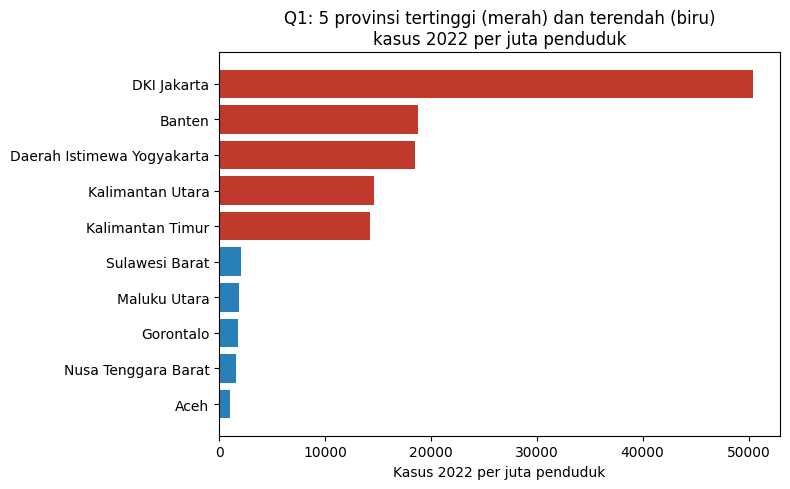

Tertinggi: ['DKI Jakarta', 'Banten', 'Daerah Istimewa Yogyakarta', 'Kalimantan Utara', 'Kalimantan Timur']
Terendah: ['Aceh', 'Nusa Tenggara Barat', 'Gorontalo', 'Maluku Utara', 'Sulawesi Barat']


In [42]:
top5 = hasil.sort_values("kasus_per_juta", ascending=False).head(5)
bot5 = hasil.sort_values("kasus_per_juta", ascending=True).head(5)
q1 = pd.concat([top5, bot5]).sort_values("kasus_per_juta")

fig, ax = plt.subplots(figsize=(8, 5))
warna = ["#c0392b" if v in top5["provinsi"].values else "#2980b9" for v in q1["provinsi"]]
ax.barh(q1["provinsi"], q1["kasus_per_juta"], color=warna)
ax.set_xlabel("Kasus 2022 per juta penduduk")
ax.set_title("Q1: 5 provinsi tertinggi (merah) dan terendah (biru)\nkasus 2022 per juta penduduk")
plt.tight_layout()
plt.savefig("hasil/grafik/q1_top5_bottom5.png", dpi=150)
plt.show()

q1.to_csv("hasil/tabel/q1_top5_bottom5.csv", index=False, encoding="utf-8")
print("Tertinggi:", top5["provinsi"].tolist())
print("Terendah:", bot5["provinsi"].tolist())

### Q2 — Kepadatan penduduk vs kasus 2022 per juta (dengan dan tanpa DKI Jakarta)

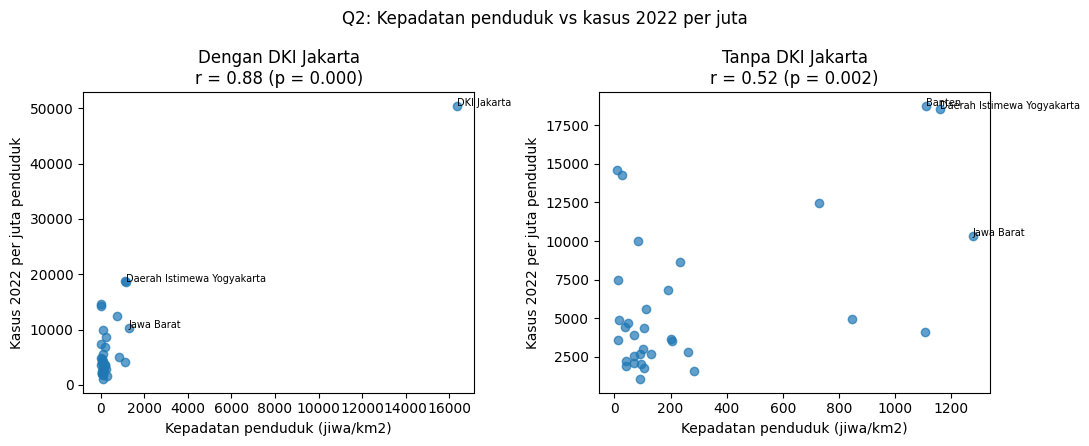

,kondisi,r,p_value,n_provinsi
0,Dengan DKI Jakarta,0.877,0.0000,34
1,Tanpa DKI Jakarta,0.523,0.0018,33


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
catatan_korelasi = []

for ax, dat, judul in [
    (axes[0], hasil, "Dengan DKI Jakarta"),
    (axes[1], hasil[hasil["provinsi"] != "DKI Jakarta"], "Tanpa DKI Jakarta"),
]:
    r, pval = pearsonr(dat["kepadatan"], dat["kasus_per_juta"])
    ax.scatter(dat["kepadatan"], dat["kasus_per_juta"], alpha=0.7)
    for _, baris in dat.nlargest(3, "kepadatan").iterrows():
        ax.annotate(baris["provinsi"], (baris["kepadatan"], baris["kasus_per_juta"]), fontsize=7)
    ax.set_xlabel("Kepadatan penduduk (jiwa/km2)")
    ax.set_ylabel("Kasus 2022 per juta penduduk")
    ax.set_title(f"{judul}\nr = {r:.2f} (p = {pval:.3f})")
    catatan_korelasi.append({"kondisi": judul, "r": round(r, 3), "p_value": round(pval, 4), "n_provinsi": len(dat)})

fig.suptitle("Q2: Kepadatan penduduk vs kasus 2022 per juta")
plt.tight_layout()
plt.savefig("hasil/grafik/q2_scatter_kepadatan.png", dpi=150)
plt.show()

korelasi_df = pd.DataFrame(catatan_korelasi)
korelasi_df.to_csv("hasil/tabel/q2_korelasi.csv", index=False, encoding="utf-8")
korelasi_df

### Q3 — Rata-rata kasus 2022 per juta, per pulau

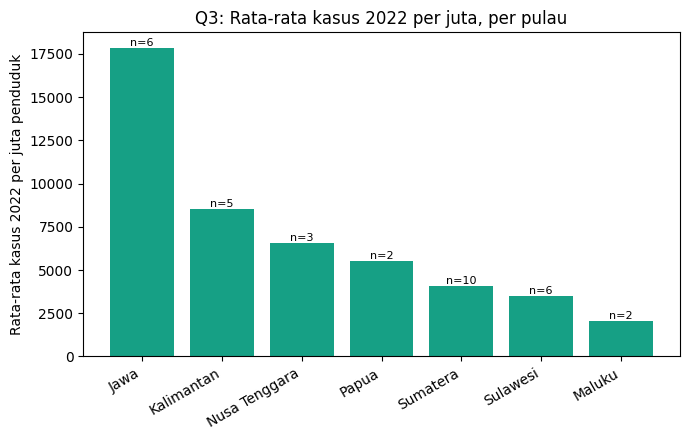

,rata2,n_provinsi
pulau,,
Jawa,17853.8,6
Kalimantan,8507.8,5
Nusa Tenggara,6537.9,3
Papua,5521.8,2
Sumatera,4092.6,10
Sulawesi,3515.6,6
Maluku,2072.7,2


In [44]:
pulau_kasus = (hasil.groupby("pulau")["kasus_per_juta"]
               .agg(rata2="mean", n_provinsi="count")
               .sort_values("rata2", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(pulau_kasus.index, pulau_kasus["rata2"], color="#16a085")
for i, (idx, baris) in enumerate(pulau_kasus.iterrows()):
    ax.text(i, baris["rata2"], f'n={int(baris["n_provinsi"])}', ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Rata-rata kasus 2022 per juta penduduk")
ax.set_title("Q3: Rata-rata kasus 2022 per juta, per pulau")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("hasil/grafik/q3_bar_pulau_kasus.png", dpi=150)
plt.show()

pulau_kasus.to_csv("hasil/tabel/q3_pulau_kasus.csv", encoding="utf-8")
pulau_kasus.round(1)

### Q4 — Rata-rata kematian 2022 per juta, per pulau

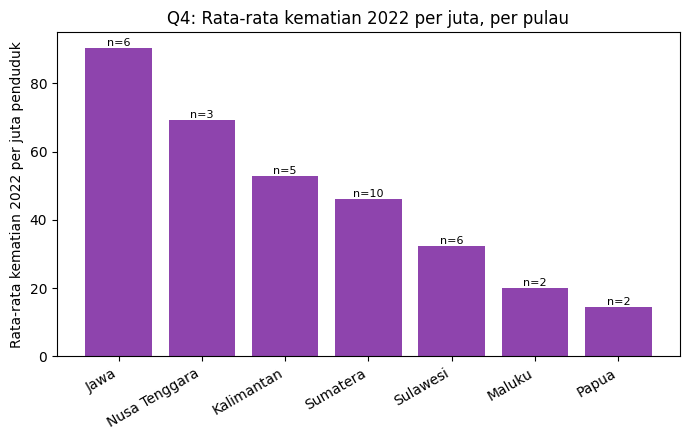

In [45]:
pulau_mati = (hasil.groupby("pulau")["kematian_per_juta"]
              .agg(rata2="mean", n_provinsi="count")
              .sort_values("rata2", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(pulau_mati.index, pulau_mati["rata2"], color="#8e44ad")
for i, (idx, baris) in enumerate(pulau_mati.iterrows()):
    ax.text(i, baris["rata2"], f'n={int(baris["n_provinsi"])}', ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Rata-rata kematian 2022 per juta penduduk")
ax.set_title("Q4: Rata-rata kematian 2022 per juta, per pulau")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("hasil/grafik/q4_bar_pulau_kematian.png", dpi=150)
plt.show()

pulau_mati.to_csv("hasil/tabel/q4_pulau_kematian.csv", encoding="utf-8")

### G5 — Daftar periksa sebelum `git push`

- [ ] `data/raw/` masuk `.gitignore`
- [ ] Tidak ada nama, NIK, nomor telepon, surel, atau alamat di berkas mana pun
- [ ] Keluaran sel yang sempat menampilkan data pribadi sudah dibersihkan
- [ ] Garam hash tidak tertulis di dalam notebook
- [ ] Kamus data memuat kategori dan tindakan untuk setiap kolom
- [ ] Nilai k pada data yang diunggah sudah dihitung dan dicatat
- [ ] Bila masih ragu: repositori dibuat **privat**

> Menghapus berkas lalu *commit* ulang **tidak** menghilangkan data dari riwayat Git. > Periksa **sebelum** *commit* pertama.